In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("Success All climate analysis tools are loaded.")

In [1]:
import pandas as pd
df = pd.read_csv('../data/ethiopia.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [2]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

Number of duplicate rows:
0


In [ ]:
#convert Year and Day into a single Date column for Ethiopia
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')

cols = ['DATE'] + [c for c in df.columns if c != 'DATE']
df = df[cols]

df.head()

,DATE,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


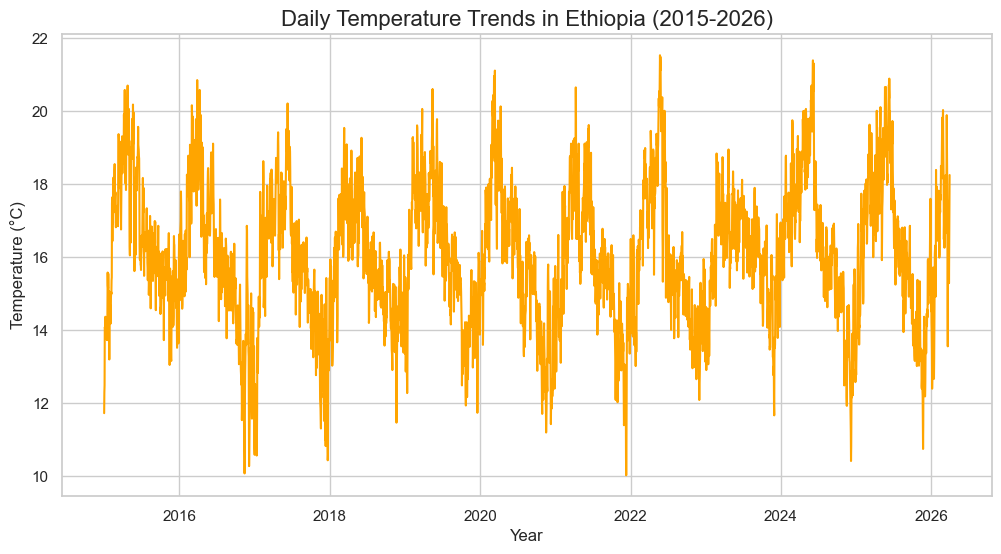

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x = 'DATE', y = 'T2M', color = 'orange')

plt.title('Daily Temperature Trends in Ethiopia (2015-2026)', fontsize = 16)
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Temperature (°C)', fontsize=12)

plt.show()

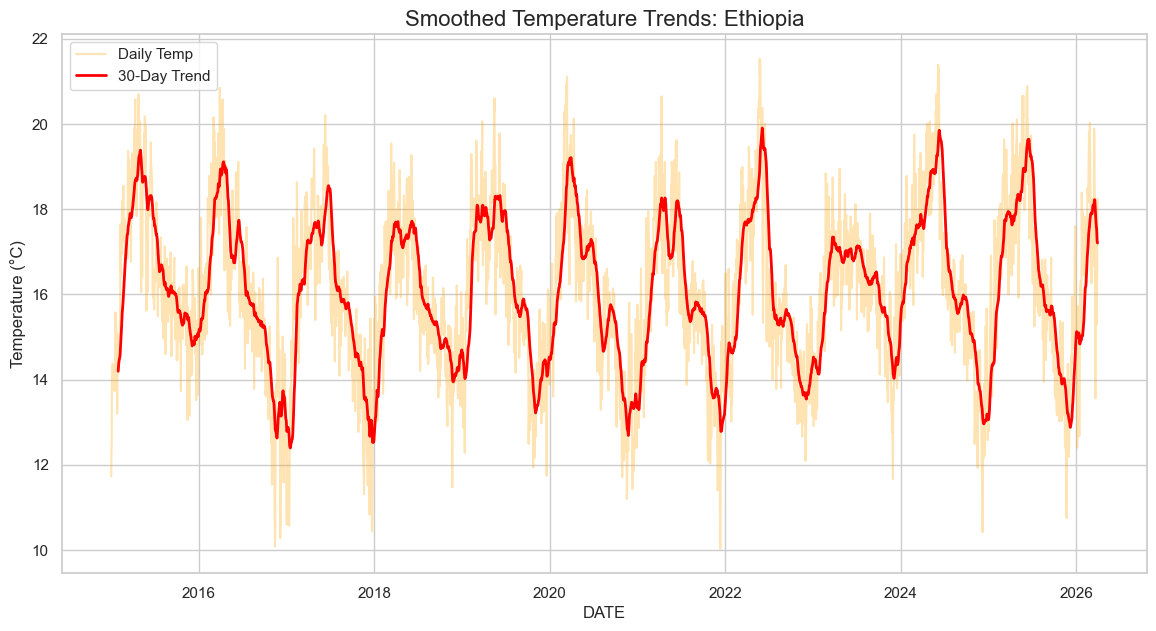

In [10]:
# Calculate a 30-day moving average
df['T2M_30day'] = df['T2M'].rolling(window=30).mean()

plt.figure(figsize=(14, 7))

sns.lineplot(data=df, x='DATE', y='T2M', color='orange', alpha=0.3, label='Daily Temp')

sns.lineplot(data=df, x='DATE', y='T2M_30day', color='red', linewidth=2, label='30-Day Trend')

plt.title('Smoothed Temperature Trends: Ethiopia', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [11]:
#load the kenya dataset
df_kenya = pd.read_csv('../data/kenya.csv')
df_kenya['DATE'] = pd.to_datetime(df_kenya['YEAR'].astype(str) + df_kenya['DOY'].astype(str), format='%Y%j')
df_kenya['T2M_30day'] = df_kenya['T2M'].rolling(window = 30).mean()
df_kenya.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,T2M_30day
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,2015-01-01,NaN
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,2015-01-02,NaN
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,2015-01-03,NaN
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,2015-01-04,NaN
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,2015-01-05,NaN


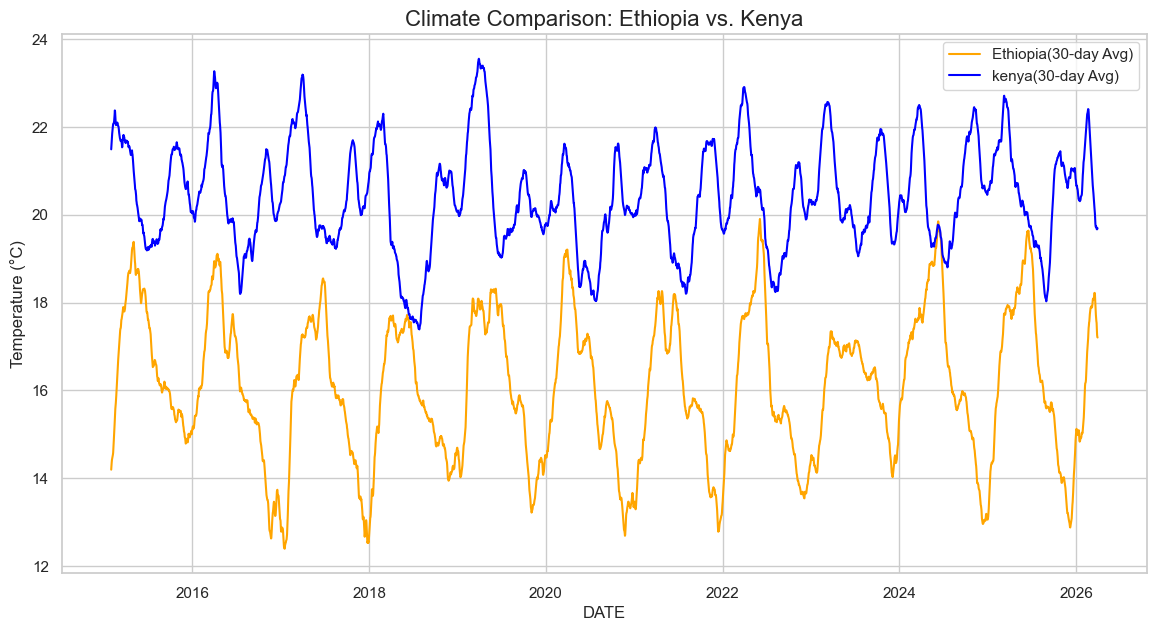

In [12]:
plt.figure(figsize = (14, 7))

sns.lineplot(data = df, x = 'DATE', y = 'T2M_30day', color = 'orange', label = 'Ethiopia(30-day Avg)')
sns.lineplot(data = df_kenya, x = 'DATE', y = 'T2M_30day', color = 'blue', label = 'kenya(30-day Avg)')

plt.title('Climate Comparison: Ethiopia vs. Kenya', fontsize = 16)
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()